In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [2]:
digits = load_digits()


In [3]:

df = pd.DataFrame(digits.data)
df['target'] = digits.target

print(df.head())


     0    1    2     3     4     5    6    7    8    9  ...   55   56   57  \
0  0.0  0.0  5.0  13.0   9.0   1.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
1  0.0  0.0  0.0  12.0  13.0   5.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
2  0.0  0.0  0.0   4.0  15.0  12.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
3  0.0  0.0  7.0  15.0  13.0   1.0  0.0  0.0  0.0  8.0  ...  0.0  0.0  0.0   
4  0.0  0.0  0.0   1.0  11.0   0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   

    58    59    60    61   62   63  target  
0  6.0  13.0  10.0   0.0  0.0  0.0       0  
1  0.0  11.0  16.0  10.0  0.0  0.0       1  
2  0.0   3.0  11.0  16.0  9.0  0.0       2  
3  7.0  13.0  13.0   9.0  0.0  0.0       3  
4  0.0   2.0  16.0   4.0  0.0  0.0       4  

[5 rows x 65 columns]


In [4]:
X = digits.data
y = digits.target


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))



Training samples: 1437
Testing samples: 360


In [6]:
model_rbf = SVC(kernel='rbf')
model_rbf.fit(X_train, y_train)

rbf_score = model_rbf.score(X_test, y_test)
print("\nRBF Kernel Accuracy:", rbf_score)


RBF Kernel Accuracy: 0.9861111111111112


In [7]:
model_linear = SVC(kernel='linear')
model_linear.fit(X_train, y_train)

linear_score = model_linear.score(X_test, y_test)
print("Linear Kernel Accuracy:", linear_score)

Linear Kernel Accuracy: 0.9777777777777777


In [8]:
best_model = SVC(kernel='rbf', C=10, gamma=0.001)

best_model.fit(X_train, y_train)

best_score = best_model.score(X_test, y_test)

print("\nBest Tuned Model Accuracy:", best_score)


Best Tuned Model Accuracy: 0.9888888888888889


In [9]:
y_pred = best_model.predict(X_test)


In [10]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       1.00      1.00      1.00        28
           2       1.00      1.00      1.00        33
           3       1.00      0.97      0.99        34
           4       1.00      1.00      1.00        46
           5       0.98      0.98      0.98        47
           6       0.97      1.00      0.99        35
           7       0.97      0.97      0.97        34
           8       1.00      1.00      1.00        30
           9       0.97      0.97      0.97        40

    accuracy                           0.99       360
   macro avg       0.99      0.99      0.99       360
weighted avg       0.99      0.99      0.99       360



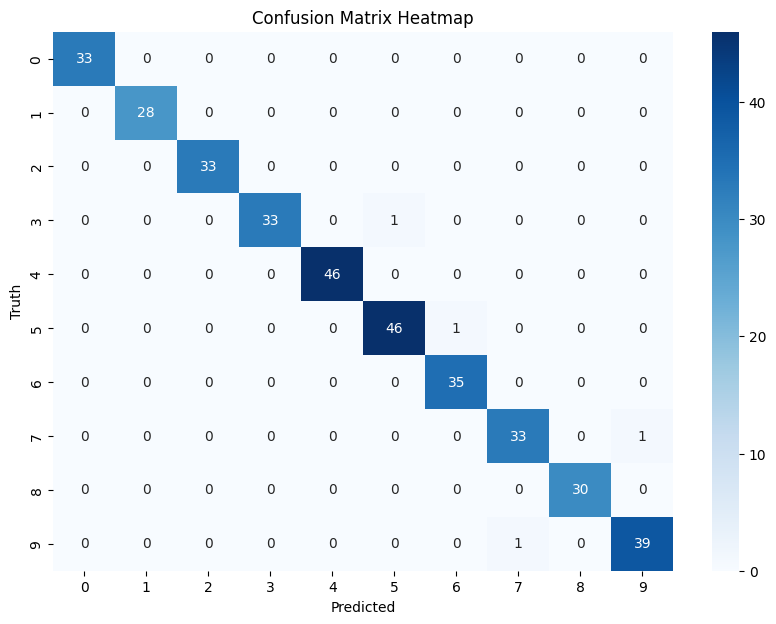

In [11]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,7))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.title('Confusion Matrix Heatmap')

plt.show()

In [12]:
print("\nClassification Report:\n")



Classification Report:



In [13]:

joblib.dump(best_model, 'svm_digits_model.pkl')

print("\nModel saved successfully as svm_digits_model.pkl")



Model saved successfully as svm_digits_model.pkl


In [14]:
loaded_model = joblib.load('svm_digits_model.pkl')


In [15]:
sample_prediction = loaded_model.predict([X_test[0]])

print("\nSample Prediction:", sample_prediction[0])
print("Actual Value:", y_test[0])


Sample Prediction: 6
Actual Value: 6
